# 04 - Asset-Class-Level Tuning

## Purpose of this notebook

In this notebook, I test a more flexible version of the tactical ETF strategy by allowing different momentum lookback windows for different asset classes.

Instead of using one shared momentum horizon for all ETFs, I now allow:
- one momentum lookback for equity ETFs
- one momentum lookback for defensive / macro ETFs

This is intended to be a middle ground between:
- the fully shared baseline model
- the more aggressive ETF-level tuning model

## Why this notebook matters

The shared baseline in Notebook 03 showed that the strategy family is promising.

Now I want to test whether a modest amount of extra flexibility improves the results in a meaningful and believable way, without introducing too much overfitting risk.

## Asset classes used in this notebook

For now, I use:
- **Equities:** SPY, QQQ, IWM, EFA, EEM
- **Defensive / Macro:** TLT, IEF, GLD

## Research goal

The main question is:

Does allowing different momentum windows by asset class improve risk-adjusted performance enough to justify the added complexity?

## 2. Import libraries

In this section, I import the libraries needed for the asset-class tuning backtest.

### What this section is doing
These imports support:
- data handling
- numerical calculations
- visualizations
- working with saved signal artifacts

### What I can change later
- I can later move reusable code into `src/`
- I can add heatmap libraries like seaborn later if I want a more polished grid search visualization

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 3. Load processed data and baseline outputs

In this section, I load the same monthly return and signal data used in the baseline backtest, along with the saved baseline performance tables for comparison.

### What this section is doing
I load:
- monthly returns
- monthly MA filter
- monthly rolling volatility
- monthly momentum tables
- baseline strategy returns
- baseline performance metrics

### Why this matters
This lets me compare the asset-class-tuned model directly against the shared baseline.

In [34]:
DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

monthly_returns = pd.read_csv(PROCESSED_DIR / "monthly_returns.csv", index_col=0, parse_dates=True)
ma_filter_monthly = pd.read_csv(PROCESSED_DIR / "ma_filter_monthly.csv", index_col=0, parse_dates=True)
rolling_vol_monthly = pd.read_csv(PROCESSED_DIR / "rolling_vol_monthly.csv", index_col=0, parse_dates=True)

momentum_60 = pd.read_csv(PROCESSED_DIR / "momentum_60d_monthly.csv", index_col=0, parse_dates=True)
momentum_120 = pd.read_csv(PROCESSED_DIR / "momentum_120d_monthly.csv", index_col=0, parse_dates=True)
momentum_180 = pd.read_csv(PROCESSED_DIR / "momentum_180d_monthly.csv", index_col=0, parse_dates=True)
momentum_252 = pd.read_csv(PROCESSED_DIR / "momentum_252d_monthly.csv", index_col=0, parse_dates=True)

baseline_returns = pd.read_csv(PROCESSED_DIR / "strategy_returns_shared_baseline.csv", index_col=0, parse_dates=True)
baseline_metrics_split = pd.read_csv(PROCESSED_DIR / "metrics_split_shared_baseline.csv", index_col=0)

momentum_tables = {
    60: momentum_60,
    120: momentum_120,
    180: momentum_180,
    252: momentum_252,
}

print("Loaded monthly returns shape:", monthly_returns.shape)
print("Loaded baseline returns shape:", baseline_returns.shape)

Loaded monthly returns shape: (253, 8)
Loaded baseline returns shape: (242, 4)


## 4. Define research split and asset classes

In this section, I define the date ranges and the ETF groupings that will be used for asset-class tuning.

### What this section is doing
I define:
- train / validation / test periods
- top K
- fallback asset
- asset-class membership

### Why this matters
These definitions control how the tuning experiment is run and make the notebook consistent with earlier stages of the project.

In [35]:
TRAIN_START = "2005-01-01"
TRAIN_END = "2014-12-31"

VALID_START = "2015-01-01"
VALID_END = "2018-12-31"

TEST_START = "2019-01-01"
TEST_END = monthly_returns.index.max().strftime("%Y-%m-%d")

TOP_K = 2
FALLBACK_ASSET = "IEF"
MOMENTUM_WINDOWS = [60, 120, 180, 252]

EQUITY_ASSETS = ["SPY", "QQQ", "IWM", "EFA", "EEM"]
DEFENSIVE_ASSETS = ["TLT", "IEF", "GLD"]

print("Equity assets:", EQUITY_ASSETS)
print("Defensive assets:", DEFENSIVE_ASSETS)

Equity assets: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
Defensive assets: ['TLT', 'IEF', 'GLD']


## 5. Align all inputs to a common monthly index

In this section, I make sure that all return and signal tables share the same monthly dates.

### Why this matters
This avoids mismatches when I later combine asset-class-specific momentum tables into one portfolio construction rule.

In [36]:
common_index = monthly_returns.index.intersection(ma_filter_monthly.index).intersection(rolling_vol_monthly.index)
for window in MOMENTUM_WINDOWS:
    common_index = common_index.intersection(momentum_tables[window].index)

common_index = common_index.sort_values()

monthly_returns = monthly_returns.loc[common_index]
ma_filter_monthly = ma_filter_monthly.loc[common_index]
rolling_vol_monthly = rolling_vol_monthly.loc[common_index]
for window in MOMENTUM_WINDOWS:
    momentum_tables[window] = momentum_tables[window].loc[common_index]

print("Common monthly observations:", len(common_index))
print("First date:", common_index.min())
print("Last date:", common_index.max())

Common monthly observations: 242
First date: 2006-01-31 00:00:00
Last date: 2026-02-27 00:00:00


## 6. Helper functions

In this section, I define reusable helper functions for:
- inverse-volatility weighting
- performance metrics
- split metrics
- asset-class-specific momentum combination

### Why this matters
These functions make the grid search cleaner and easier to audit.

In [37]:
def inverse_vol_weights(vol_series):
    vol_series = vol_series.replace(0, np.nan).dropna()
    if len(vol_series) == 0:
        return pd.Series(dtype=float)
    inv_vol = 1 / vol_series
    return inv_vol / inv_vol.sum()


def compute_metrics(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return {}

    cumulative = (1 + return_series).cumprod()
    total_months = len(return_series)

    cagr = cumulative.iloc[-1] ** (12 / total_months) - 1
    ann_vol = return_series.std() * np.sqrt(12)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan

    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    max_dd = drawdown.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


def compute_split_metrics(return_series, train_start, train_end, valid_start, valid_end, test_start, test_end):
    train = return_series.loc[train_start:train_end]
    valid = return_series.loc[valid_start:valid_end]
    test = return_series.loc[test_start:test_end]

    train_metrics = compute_metrics(train)
    valid_metrics = compute_metrics(valid)
    test_metrics = compute_metrics(test)

    return {
        "Train Sharpe": train_metrics.get("Sharpe"),
        "Valid Sharpe": valid_metrics.get("Sharpe"),
        "Test Sharpe": test_metrics.get("Sharpe"),
        "Train CAGR": train_metrics.get("CAGR"),
        "Valid CAGR": valid_metrics.get("CAGR"),
        "Test CAGR": test_metrics.get("CAGR"),
        "Train MaxDD": train_metrics.get("Max Drawdown"),
        "Valid MaxDD": valid_metrics.get("Max Drawdown"),
        "Test MaxDD": test_metrics.get("Max Drawdown"),
    }

## 7. Build a mixed momentum table by asset class

In this section, I create a combined momentum table where:
- equity ETFs use one chosen lookback
- defensive ETFs use another chosen lookback

### Why this matters
This is the core idea of asset-class-level tuning.

In [38]:
def build_asset_class_momentum_table(equity_window, defensive_window, momentum_tables, equity_assets, defensive_assets):
    equity_mom = momentum_tables[equity_window][equity_assets]
    defensive_mom = momentum_tables[defensive_window][defensive_assets]
    combined = pd.concat([equity_mom, defensive_mom], axis=1)
    return combined

## 8. Portfolio construction with asset-class-level tuning

In this section, I convert the mixed momentum table into monthly portfolio weights.

### What this section is doing
I apply the same general rules as before:
- moving average filter
- top K selection
- inverse-vol weighting
- fallback to IEF

The only difference is that momentum now comes from different lookback windows depending on the asset class.

In [39]:
def generate_weight_table(momentum_df, ma_filter_df, vol_df, top_k=2, fallback_asset="IEF"):
    assets = momentum_df.columns.tolist()
    weight_records = []

    for dt in momentum_df.index:
        momentum_today = momentum_df.loc[dt]
        ma_today = ma_filter_df.loc[dt]
        vol_today = vol_df.loc[dt]

        weights = pd.Series(0.0, index=assets)

        eligible = momentum_today[ma_today].dropna().sort_values(ascending=False)
        selected_assets = eligible.head(top_k).index.tolist()

        if len(selected_assets) > 0:
            selected_vol = vol_today.loc[selected_assets].dropna()
            selected_weights = inverse_vol_weights(selected_vol)

            for asset, w in selected_weights.items():
                weights[asset] = w

        weight_sum = weights.sum()

        if weight_sum < 1.0:
            weights[fallback_asset] += (1.0 - weight_sum)

        weight_records.append(weights)

    return pd.DataFrame(weight_records, index=momentum_df.index)

## 9. Grid search across asset-class momentum combinations

In this section, I test all combinations of:
- equity momentum window
- defensive momentum window

### What this section is doing
For each pair of lookback windows, I:
- build the mixed momentum table
- generate portfolio weights
- shift weights by one month
- compute realized returns
- compute train / validation / test metrics

### Why this matters
This is the core experiment of the notebook.

In [40]:
results = {}
metrics_rows = []

for eq_window in MOMENTUM_WINDOWS:
    for def_window in MOMENTUM_WINDOWS:
        label = f"EQ_{eq_window}_DEF_{def_window}"

        mixed_momentum = build_asset_class_momentum_table(
            equity_window=eq_window,
            defensive_window=def_window,
            momentum_tables=momentum_tables,
            equity_assets=EQUITY_ASSETS,
            defensive_assets=DEFENSIVE_ASSETS,
        )

        weights = generate_weight_table(
            momentum_df=mixed_momentum,
            ma_filter_df=ma_filter_monthly[mixed_momentum.columns],
            vol_df=rolling_vol_monthly[mixed_momentum.columns],
            top_k=TOP_K,
            fallback_asset=FALLBACK_ASSET,
        )

        shifted_weights = weights.shift(1)
        returns = (shifted_weights * monthly_returns[mixed_momentum.columns]).sum(axis=1, min_count=1)

        results[label] = {
            "weights": weights,
            "shifted_weights": shifted_weights,
            "returns": returns,
        }

        full_metrics = compute_metrics(returns)
        split_metrics = compute_split_metrics(
            returns,
            TRAIN_START, TRAIN_END,
            VALID_START, VALID_END,
            TEST_START, TEST_END
        )

        row = {
            "Model": label,
            "Equity Window": eq_window,
            "Defensive Window": def_window,
            **full_metrics,
            **split_metrics,
        }
        metrics_rows.append(row)

asset_class_metrics = pd.DataFrame(metrics_rows).set_index("Model")
asset_class_metrics.head()

,Equity Window,Defensive Window,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar,Train Sharpe,Valid Sharpe,Test Sharpe,Train CAGR,Valid CAGR,Test CAGR,Train MaxDD,Valid MaxDD,Test MaxDD
Model,,,,,,,,,,,,,,,,
EQ_60_DEF_60,60,60,0.123161,0.126813,0.971206,-0.230909,0.533378,1.182983,0.311848,1.044502,0.152080,0.033659,0.139817,-0.150569,-0.202726,-0.230909
EQ_60_DEF_120,60,120,0.119738,0.123893,0.966466,-0.230909,0.518553,1.126174,0.279746,1.131494,0.149025,0.030821,0.135589,-0.107750,-0.218156,-0.230909
EQ_60_DEF_180,60,180,0.121874,0.123317,0.988295,-0.237475,0.513207,1.306640,0.133353,1.069273,0.165288,0.015239,0.131457,-0.090882,-0.224864,-0.237475
EQ_60_DEF_252,60,252,0.120764,0.122589,0.985113,-0.227819,0.530088,1.246892,0.165652,1.066162,0.158542,0.016434,0.135758,-0.097064,-0.198619,-0.227819
EQ_120_DEF_60,120,60,0.108613,0.126912,0.855816,-0.244820,0.443646,1.129764,0.501997,0.709065,0.144377,0.057571,0.094081,-0.167763,-0.190997,-0.244820


## 10. Rank asset-class-tuned models

In this section, I rank the tested models using validation and test performance.

### Why this matters
I want to identify the most promising asset-class-tuned candidate without relying only on in-sample performance.

In [41]:
ranked_asset_class_models = asset_class_metrics.sort_values(
    ["Valid Sharpe", "Test Sharpe", "Valid CAGR", "Test CAGR"],
    ascending=False
)

ranked_asset_class_models.head(10)

,Equity Window,Defensive Window,CAGR,Annual Vol,Sharpe,Max Drawdown,Calmar,Train Sharpe,Valid Sharpe,Test Sharpe,Train CAGR,Valid CAGR,Test CAGR,Train MaxDD,Valid MaxDD,Test MaxDD
Model,,,,,,,,,,,,,,,,
EQ_180_DEF_180,180,180,0.114866,0.121534,0.945130,-0.238701,0.481210,0.866930,0.617893,1.225022,0.108669,0.071566,0.147721,-0.115345,-0.143657,-0.238701
EQ_120_DEF_120,120,120,0.124122,0.128584,0.965302,-0.244820,0.506995,1.132896,0.613173,0.928628,0.154989,0.069800,0.117333,-0.157982,-0.171450,-0.244820
EQ_180_DEF_252,180,252,0.134585,0.120706,1.114986,-0.225921,0.595717,1.167242,0.574130,1.335699,0.143845,0.063494,0.164473,-0.108815,-0.133160,-0.225921
EQ_252_DEF_120,252,120,0.092142,0.123508,0.746036,-0.225921,0.407850,0.842570,0.520606,0.733146,0.107638,0.054367,0.094456,-0.215244,-0.124227,-0.225921
EQ_120_DEF_60,120,60,0.108613,0.126912,0.855816,-0.244820,0.443646,1.129764,0.501997,0.709065,0.144377,0.057571,0.094081,-0.167763,-0.190997,-0.244820
EQ_180_DEF_120,180,120,0.105638,0.122710,0.860877,-0.225921,0.467589,0.793915,0.485991,1.159795,0.104580,0.053478,0.137220,-0.163500,-0.130421,-0.225921
EQ_252_DEF_60,252,60,0.087071,0.130554,0.666938,-0.304280,0.286155,0.536096,0.418871,0.958823,0.074834,0.041638,0.129077,-0.304280,-0.132523,-0.225921
EQ_180_DEF_60,180,60,0.077149,0.128857,0.598717,-0.290765,0.265331,0.560080,0.397194,0.748782,0.076726,0.043548,0.096907,-0.290765,-0.138659,-0.228047
EQ_252_DEF_180,252,180,0.107415,0.126918,0.846338,-0.240328,0.446952,0.852548,0.380507,1.074131,0.110502,0.042682,0.141318,-0.240328,-0.137374,-0.225921


## 11. Compare the best asset-class model against the shared baseline

In this section, I compare the top asset-class-tuned candidate against the shared baseline strategies from Notebook 03.

### Why this matters
The asset-class-tuned model should only be considered useful if it improves meaningfully over the simpler shared-parameter baseline.

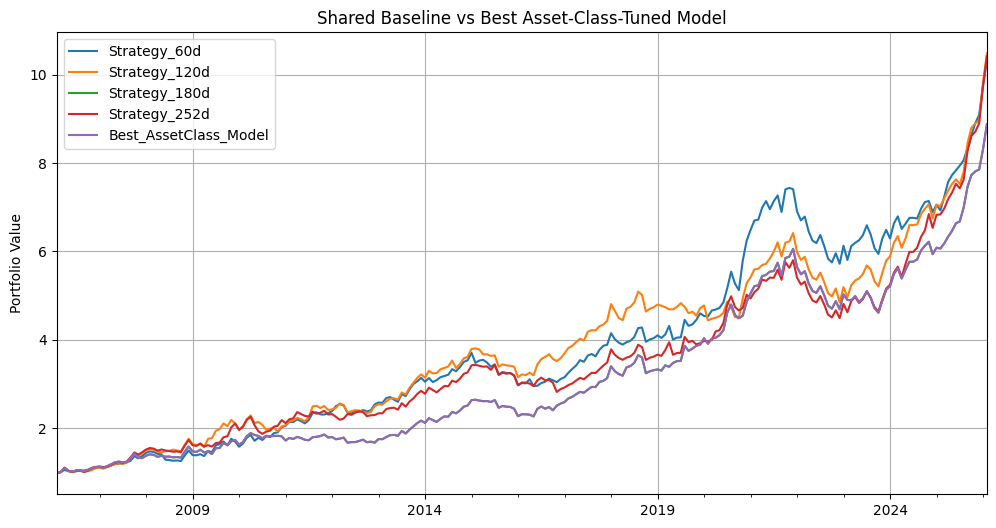

('EQ_180_DEF_180',
 Equity Window       180.000000
 Defensive Window    180.000000
 CAGR                  0.114866
 Annual Vol            0.121534
 Sharpe                0.945130
 Max Drawdown         -0.238701
 Calmar                0.481210
 Train Sharpe          0.866930
 Valid Sharpe          0.617893
 Test Sharpe           1.225022
 Train CAGR            0.108669
 Valid CAGR            0.071566
 Test CAGR             0.147721
 Train MaxDD          -0.115345
 Valid MaxDD          -0.143657
 Test MaxDD           -0.238701
 Name: EQ_180_DEF_180, dtype: float64)

In [42]:
best_asset_class_model = ranked_asset_class_models.index[0]
best_asset_class_returns = results[best_asset_class_model]["returns"]

comparison_returns = pd.concat(
    [
        baseline_returns,
        best_asset_class_returns.rename("Best_AssetClass_Model"),
    ],
    axis=1
).dropna()

comparison_cumulative = (1 + comparison_returns).cumprod()
comparison_cumulative.plot(title="Shared Baseline vs Best Asset-Class-Tuned Model")
plt.ylabel("Portfolio Value")
plt.show()

best_asset_class_model, ranked_asset_class_models.loc[best_asset_class_model]

## 12. Visualize validation Sharpe across the asset-class grid

In this section, I reshape the grid results to see whether the performance landscape looks stable or fragile.

### Why this matters
A stable region is much more believable than one isolated lucky parameter pair.

In [43]:
validation_sharpe_grid = asset_class_metrics.pivot(
    index="Equity Window",
    columns="Defensive Window",
    values="Valid Sharpe"
)

validation_sharpe_grid

Defensive Window,60,120,180,252
Equity Window,,,,
60,0.311848,0.279746,0.133353,0.165652
120,0.501997,0.613173,0.324126,0.134246
180,0.397194,0.485991,0.617893,0.574130
252,0.418871,0.520606,0.380507,0.243556


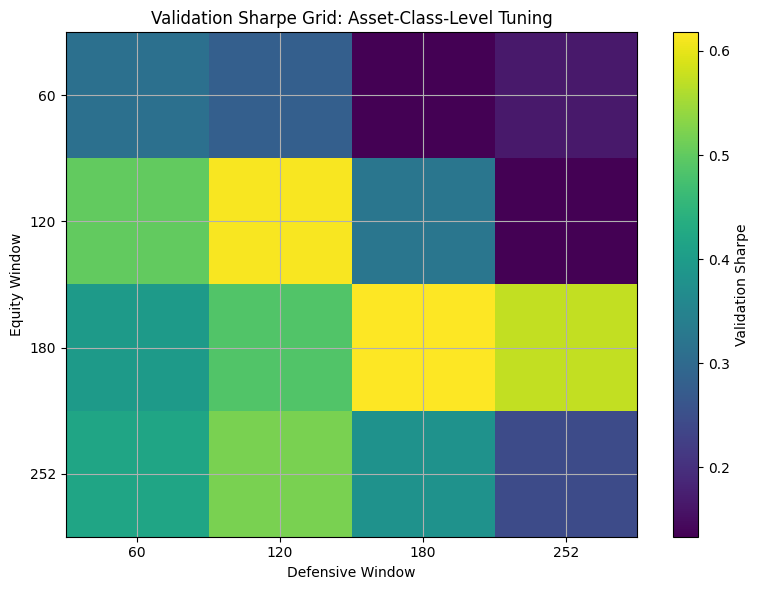

In [44]:
plt.figure(figsize=(8, 6))
plt.imshow(validation_sharpe_grid, aspect="auto")
plt.colorbar(label="Validation Sharpe")
plt.xticks(range(len(validation_sharpe_grid.columns)), validation_sharpe_grid.columns)
plt.yticks(range(len(validation_sharpe_grid.index)), validation_sharpe_grid.index)
plt.xlabel("Defensive Window")
plt.ylabel("Equity Window")
plt.title("Validation Sharpe Grid: Asset-Class-Level Tuning")
plt.tight_layout()
plt.show()

## 13. Inspect the best asset-class model's weights

In this section, I inspect the monthly weight table for the best-performing asset-class-tuned model.

### Why this matters
This helps verify that the portfolio logic still behaves sensibly under the tuned model.

In [45]:
best_weights = results[best_asset_class_model]["shifted_weights"].copy()
best_weights["WeightSum"] = best_weights.sum(axis=1)
display(best_weights.head(12))

,SPY,QQQ,IWM,EFA,EEM,TLT,IEF,GLD,WeightSum
2006-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2006-02-28,0.0,0.0,0.0,0.000000,0.499743,0.0,0.0,0.500257,1.0
2006-03-31,0.0,0.0,0.0,0.000000,0.489035,0.0,0.0,0.510965,1.0
2006-04-28,0.0,0.0,0.0,0.000000,0.455195,0.0,0.0,0.544805,1.0
2006-05-31,0.0,0.0,0.0,0.000000,0.507230,0.0,0.0,0.492770,1.0
2006-06-30,0.0,0.0,0.0,0.644127,0.000000,0.0,0.0,0.355873,1.0
2006-07-31,0.0,0.0,0.0,0.000000,0.480489,0.0,0.0,0.519511,1.0
2006-08-31,0.0,0.0,0.0,0.000000,0.424610,0.0,0.0,0.575390,1.0
2006-09-29,0.0,0.0,0.0,0.573737,0.000000,0.0,0.0,0.426263,1.0
2006-10-31,0.0,0.0,0.0,0.612108,0.000000,0.0,0.0,0.387892,1.0


## 14. Save asset-class tuning outputs

In this section, I save the key outputs from the asset-class tuning experiment.

### What this section is doing
I save:
- full metrics table
- ranked metrics table
- best model returns
- best model weights

In [46]:
asset_class_metrics.to_csv(PROCESSED_DIR / "asset_class_tuning_metrics.csv")
ranked_asset_class_models.to_csv(PROCESSED_DIR / "asset_class_tuning_ranked.csv")
best_asset_class_returns.to_csv(PROCESSED_DIR / "best_asset_class_returns.csv")
best_weights.to_csv(PROCESSED_DIR / "best_asset_class_weights.csv")

print("Saved asset-class tuning outputs to:", PROCESSED_DIR.resolve())

Saved asset-class tuning outputs to: /Users/nicholasturangan/Desktop/quant/quant-portfolio-project/data/processed


## 15. Key takeaways from this notebook

At this stage, I have tested whether a modest increase in model flexibility improves the tactical ETF strategy.

### What I accomplished
- defined equity and defensive asset classes
- tested a grid of momentum windows by asset class
- backtested each asset-class combination
- evaluated performance across train, validation, and test
- compared the best tuned model against the shared baseline

### What I learned
This notebook helps answer whether asset-class-level tuning provides a meaningful improvement over the simpler shared-parameter model.

### What comes next
The next branch of the project is the more aggressive research path:
- ETF-level tuning

That notebook will test whether individual ETFs benefit from custom lookback windows, and whether that added flexibility is actually worth the added complexity.